<a href="https://colab.research.google.com/github/DavidRamosArchilla/Colorizing-images/blob/main/image_colorization_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Make sure that GPU is enabled

To do that, go to `Runtime > Change Runtime type`
- `Hardware Accelerator > GPU`

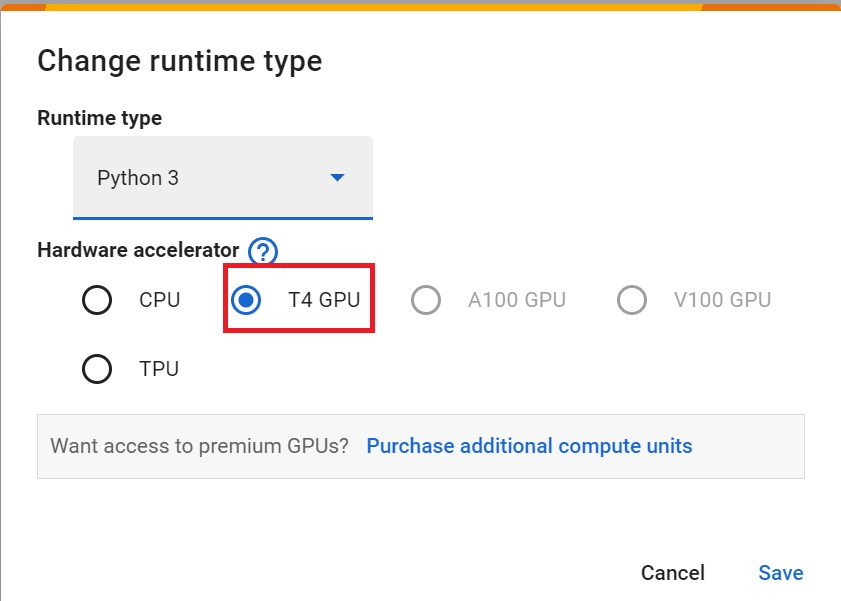

# Clone the repo and import the required libraries

In [1]:
!git clone https://github.com/DavidRamosArchilla/Colorizing-images.git

Cloning into 'Colorizing-images'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 3), reused 15 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 717.49 KiB | 1.95 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [1]:
%cd Colorizing-images

[WinError 2] Le fichier spécifié est introuvable: 'Colorizing-images'
C:\Users\96176\PycharmProjects\Image colorization\Colorizing-images


C:\Users\96176\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [2]:
from utils import visualize_results
import torch
import numpy as np
from models import ColorizingNet
from utils import ColirizationDataset
from PIL import Image
from torchvision import transforms
import os
import matplotlib.pyplot as plt

# Download the pretrained model from Huggingface Hub and load the weights

In [4]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="davidramos/image-colorization",
    filename="model.pth"
)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ColorizingNet(device)
model.load_state_dict(torch.load(model_path,weights_only=True,map_location=device))

RuntimeError: Error(s) in loading state_dict for ColorizingNet:
	Missing key(s) in state_dict: "generator.encoder.0.0.bias", "generator.encoder.0.1.weight", "generator.encoder.0.1.bias", "generator.encoder.0.1.running_mean", "generator.encoder.0.1.running_var", "generator.encoder.1.0.bias", "generator.encoder.2.0.bias", "generator.encoder.3.0.bias", "generator.bottleneck.0.weight", "generator.bottleneck.0.bias", "generator.bottleneck.1.weight", "generator.bottleneck.1.bias", "generator.bottleneck.1.running_mean", "generator.bottleneck.1.running_var", "generator.decoder.0.0.bias", "generator.decoder.1.0.bias", "generator.decoder.2.0.bias", "generator.decoder.3.0.bias", "generator.final_layer.weight", "generator.final_layer.bias". 
	Unexpected key(s) in state_dict: "generator.encoder.4.0.weight", "generator.encoder.4.1.weight", "generator.encoder.4.1.bias", "generator.encoder.4.1.running_mean", "generator.encoder.4.1.running_var", "generator.encoder.4.1.num_batches_tracked", "generator.e

# Download test data

In [18]:
!mkdir data

Un sous-r‚pertoire ou un fichier data existe d‚j….


In [22]:
from download_datasets import download_coco
download_coco('data', 'val')

data\val2017.zip: 100%|██████████| 778M/778M [01:13<00:00, 11.2MiB/s] 


Extracting files...


## Create the dataloaders

In [10]:
val_dir = 'data/val2017'
transformation = transforms.Compose([
    transforms.Resize((256, 256), Image.BICUBIC),
    transforms.ToTensor(),
])
imgs_val = np.random.choice(os.listdir(val_dir), 1000).tolist()
imgs_val = [os.path.join(val_dir, img) for img in imgs_val]
val_dataset = ColirizationDataset(imgs_val, transformation)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=True)

# And finally, try the model!

In [9]:
visualize_results(model, val_loader, device, 0, show=True, num_images=5)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 256 and the array at index 1 has size 128

# Upload input

C:\Users\96176\AppData\Local\Temp\ipykernel_28880\1679876523.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=d

Visualizing Results...


<Figure size 2000x2000 with 0 Axes>

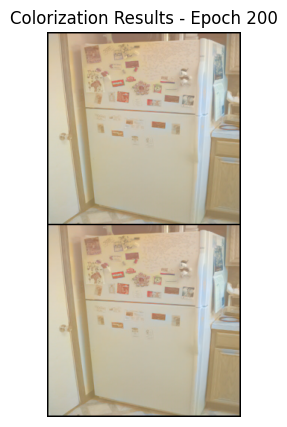

In [35]:
from utils import visualize_results
import torch
import numpy as np
from models import ColorizingNet
from utils import ColirizationDataset
from PIL import Image
from torchvision import transforms
import os
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# Function to load and process a black-and-white image
def load_bw_image(image_path, target_size=(256, 256)):
    """
    Load a black-and-white image, resize it, and ensure it has 1 channel.
    """
    # Open the image and convert it to grayscale
    img = Image.open(image_path).convert("L")  # "L" mode ensures 1 channel (grayscale)

    # Apply transformations: resize and convert to tensor
    transformation = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),  # Converts to [1, H, W]
    ])
    img_tensor = transformation(img).unsqueeze(0)  # Add batch dimension
    return img, img_tensor

# Function to process the image and visualize results
def process_image(image_path):
    """
    Processes the image: prepares it for the model and visualizes the output.
    """
    try:
        # Load the model
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = ColorizingNet(device)
        model_path = hf_hub_download(
            repo_id="davidramos/image-colorization",
            filename="model.pth"
        )
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval()

        # Load and preprocess the black-and-white image
        original_img, bw_tensor = load_bw_image(image_path, target_size=(256, 256))
        bw_tensor = bw_tensor.to(device)

        # Forward pass to colorize the image
        with torch.no_grad():
            output = model(bw_tensor)

        # Visualize the results
        print("Visualizing Results...")
        visualize_results(model, [(bw_tensor, output)], device, epoch=200, show=True, num_images=1)

    except Exception as e:
        print(f"An error occurred: {e}")

# Path to your image
image_path = "data/img_color/data/test_black/image5023.jpg"
process_image(image_path)
